# IRLS step-by-step: 755252_2024-11-19, VISp_0 roi_index=29 (cell_roi_id=36)

Reproduces the exact fitting settings from `long_vs_short_baseline_window.ipynb` and shows the state
at each outer IRLS iteration: F0trend, per-frame weights, inlier fraction, parameter values.



In [12]:
from pathlib import Path
import numpy as np
import pandas as pd
import jax
import jax.numpy as jnp
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from aind_ophys_utils.signal_utils import noise_std
from baseline_fitting import AsymmetricTukeyBiweight, fit_baseline 

%matplotlib inline
%config InlineBackend.close_figures = True

In [13]:
session_key = '755252_2024-11-19'
plane_id    = 'VISp_0'
roi_index   = 29 -1  # 1-based index within VISp_0 valid ROIs

save_dir = Path('/root/capsule/scratch/first_try') / session_key

F_all          = np.load(save_dir / 'F_all_array.npy')
timestamps     = np.load(save_dir / 'timestamps.npy')
F_noise_all    = np.load(save_dir / 'F_noise.npy')
baseline_long  = np.load(save_dir / 'baseline_long_window_all_array.npy')
F0trend_saved  = np.load(save_dir / 'F0trend_all.npy')

# VISp_0 is the first plane -> global_idx = roi_index (no offset)
global_idx = roi_index

# Verify cell_roi_id
roi_table  = pd.read_pickle(save_dir / f'{plane_id}_roi_table.pkl')
valid_rois = roi_table.query('valid_roi').reset_index(drop=True)
cell_roi_id = int(valid_rois.iloc[roi_index].cell_roi_id)
print(f'plane={plane_id}, roi_index={roi_index} -> cell_roi_id={cell_roi_id}')

F              = F_all[global_idx]
fixed_sigma    = float(F_noise_all[global_idx])
b_init         = float(np.mean(F - baseline_long[global_idx]))

print(f'F range        : [{F.min():.1f}, {F.max():.1f}]  mean={F.mean():.1f}')
print(f'fixed_sigma    : {fixed_sigma:.2f}  (F_noise)')
print(f'b_init         : {b_init:.2f}  (mean(F - baseline_long))')
print(f'Saved F0trend  : [{F0trend_saved[global_idx].min():.1f}, {F0trend_saved[global_idx].max():.1f}]')

plane=VISp_0, roi_index=28 -> cell_roi_id=35
F range        : [431.9, 3113.3]  mean=1156.0
fixed_sigma    : 103.57  (F_noise)
b_init         : 251.38  (mean(F - baseline_long))
Saved F0trend  : [-748.1, 372.2]


In [23]:
# ── Exact settings from long_vs_short_baseline_window.ipynb ──────────────────

def model(params, t, xp=np):
    b_inf, b_slow, b_fast, b_bright, t_slow, t_fast, t_bright = params
    E_slow   = xp.exp(-t / t_slow)
    E_fast   = xp.exp(-t / t_fast)
    E_bright = xp.exp(-t / t_bright)
    return b_inf + b_slow * E_slow + b_fast * E_fast - b_bright * E_bright

c_pos=2
c_neg=4
M          = AsymmetricTukeyBiweight(c_pos=c_pos, c_neg=c_neg)
t_max      = float(timestamps[-1])
t_high_bound = t_max * 2

x0 = [
    float(F.mean()),   # b_inf
    b_init,            # b_slow
    b_init,            # b_fast
    b_init,            # b_bright
    t_max / 2,         # t_slow
    60.0,              # t_fast
    t_max / 2,         # t_bright
]

bounds = [
    (0, None),          # b_inf
    (0, None),          # b_slow
    (0, None),          # b_fast
    (0, None),          # b_bright
    (300, t_high_bound),# t_slow
    (1, 300),           # t_fast  <- constrained < 5 min
    (300, t_high_bound),# t_bright
]

PARAM_LABELS = ['b_inf', 'b_slow', 'b_fast', 'b_bright', 't_slow', 't_fast', 't_bright']

dtype = jnp.float32
t_    = jnp.asarray(timestamps, dtype=dtype)
y_    = jnp.asarray(F, dtype=dtype)

print('x0:', dict(zip(PARAM_LABELS, [f'{v:.2f}' for v in x0])))
print(f'fixed_sigma = F_noise = {fixed_sigma:.2f}')
print(f'c_pos={M.c_pos}, c_neg={M.c_neg}')
print(f'inlier window: resid in [{-M.c_neg*fixed_sigma:.1f}, +{M.c_pos*fixed_sigma:.1f}]')

x0: {'b_inf': '1155.99', 'b_slow': '251.38', 'b_fast': '251.38', 'b_bright': '251.38', 't_slow': '1821.26', 't_fast': '60.00', 't_bright': '1821.26'}
fixed_sigma = F_noise = 103.57
c_pos=2, c_neg=4
inlier window: resid in [-414.3, +207.1]


In [24]:
def _fit_one(F, x0, noise):
    F0, F0trend, res, info = fit_baseline(
        F, timestamps, model,
        x0,
        bounds=bounds,
        M=M,
        fixed_sigma=noise,
        backend="jax", dtype=jnp.float32)
    ls = info['lowess_sigma'] * F0trend
    loss = np.mean(M.rho((F - F0) / ls) * ls**2)
    return F0trend, F0, res, loss, info

F0trend, F0, res, loss,info = _fit_one(F, x0, fixed_sigma)

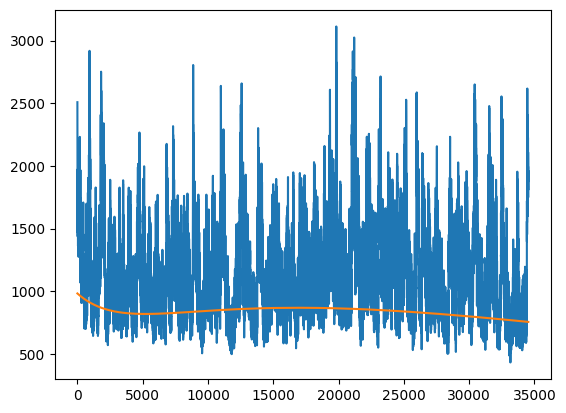

In [25]:
fig, ax = plt.subplots()
ax.plot(F)
ax.plot(F0trend)

In [26]:
# ── JAX objectives (mirrors nonlinear_fit internals) ─────────────────────────
# model() uses xp=np by default, which fails inside JAX JIT (np.exp cannot
# trace a JAX abstract value).  Pass xp=jnp and use M_jax inside traced fns.

M_jax = AsymmetricTukeyBiweight(c_pos=M.c_pos, c_neg=M.c_neg, xp=jnp)

def _ols_loss(theta):
    r = y_ - model(theta, t_, xp=jnp)
    return jnp.sum(r ** 2)

def _robust_loss(theta, sigma):
    u = (y_ - model(theta, t_, xp=jnp)) / sigma
    return jnp.sum(M_jax.rho(u))

ols_val_grad    = jax.jit(jax.value_and_grad(_ols_loss))
robust_val_grad = jax.jit(jax.value_and_grad(_robust_loss))

def _make_optimizer_fns(val_grad_fn, *extra_args):
    """Wrap a JAX val_grad function into scipy.minimize-compatible (fun, jac) pair."""
    cache = {}
    def fun(theta):
        val, grad = val_grad_fn(jnp.asarray(theta, dtype=dtype), *extra_args)
        cache['g'] = np.array(grad)
        return float(val)
    jac = lambda theta: cache['g']
    return fun, jac

def _get_weights_and_inlier_frac(params, sigma):
    # Called outside JIT with concrete values — xp=jnp still safe here
    F0t   = np.array(model(jnp.asarray(params, dtype=dtype), t_, xp=jnp))
    resid = np.array(y_) - F0t
    u     = resid / sigma
    w     = np.array(M.weights(u))   # M with xp=np fine on concrete numpy u
    inlier_frac = float((w > 0).mean())
    return F0t, resid, u, w, inlier_frac

In [27]:
# ── Step-by-step IRLS (maxiter=5, tol=1e-3, same as nonlinear_fit defaults) ──
# NOTE: nonlinear_fit hands scipy a jnp.asarray(x0, dtype=float32) initial guess
# AND options={maxiter:20000, ftol:1e-12, gtol:1e-10}. Both are required to
# reproduce its trajectory: the float32 dtype propagates into scipy's L-BFGS-B
# state and line search (the OLS landscape is degenerate enough that the
# float32 vs float64 path lands in different basins).

history = []

x0_f32        = jnp.asarray(x0, dtype=dtype)            # match nonlinear_fit
minimize_opts = {'maxiter': 20000, 'ftol': 1e-12, 'gtol': 1e-10}

# ── OLS pre-pass ──────────────────────────────────────────────────────────────
fun, jac = _make_optimizer_fns(ols_val_grad)
res_ols  = minimize(fun, x0_f32, bounds=bounds, method='L-BFGS-B', jac=jac,
                    options=minimize_opts)
x        = jnp.asarray(res_ols.x, dtype=dtype)

F0t_ols, resid_ols, u_ols, w_ols, inlier_ols = _get_weights_and_inlier_frac(x, fixed_sigma)

history.append({
    'step'         : 'OLS',
    'params'       : np.array(x),
    'F0trend'      : F0t_ols,
    'resid'        : resid_ols,
    'u'            : u_ols,
    'weights'      : w_ols,
    'inlier_frac'  : inlier_ols,   # what IRLS iteration 1 will see
    'param_change' : None,
})

print(f"OLS:  F0trend=[{F0t_ols.min():.1f}, {F0t_ols.max():.1f}]  "
      f"inlier_frac (under fixed_sigma)={inlier_ols:.1%}")

# ── IRLS iterations ───────────────────────────────────────────────────────────
sigma  = fixed_sigma  # constant throughout (fixed_sigma path)
maxiter, tol = 5, 1e-3

for i_iter in range(maxiter):
    fun, jac  = _make_optimizer_fns(robust_val_grad, sigma)
    res_iter  = minimize(fun, x, bounds=bounds, method='L-BFGS-B', jac=jac,
                         options=minimize_opts)
    x_new     = jnp.asarray(res_iter.x, dtype=dtype)

    F0t_new, resid_new, u_new, w_new, inlier_new = _get_weights_and_inlier_frac(x_new, sigma)

    param_change = float(
        np.linalg.norm(np.array(x_new) - np.array(x))
        / (np.linalg.norm(np.array(x)) + 1e-12)
    )

    history.append({
        'step'         : f'IRLS {i_iter+1}',
        'params'       : np.array(x_new),
        'F0trend'      : F0t_new,
        'resid'        : resid_new,
        'u'            : u_new,
        'weights'      : w_new,
        'inlier_frac'  : inlier_new,
        'param_change' : param_change,
    })

    print(f"IRLS {i_iter+1}: F0trend=[{F0t_new.min():.1f}, {F0t_new.max():.1f}]  "
          f"inlier={inlier_new:.1%}  param_change={param_change:.2e}")

    x = x_new
    if param_change < tol:
        print(f"  -> converged (param_change < {tol})")
        break

print(f"\nTotal steps recorded: {len(history)}")

OLS:  F0trend=[1071.4, 1461.8]  inlier_frac (under fixed_sigma)=70.7%
IRLS 1: F0trend=[755.7, 982.8]  inlier=46.0%  param_change=6.58e-02
IRLS 2: F0trend=[755.7, 982.8]  inlier=46.0%  param_change=2.26e-07
  -> converged (param_change < 0.001)

Total steps recorded: 3


/tmp/ipykernel_7704/2820177753.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


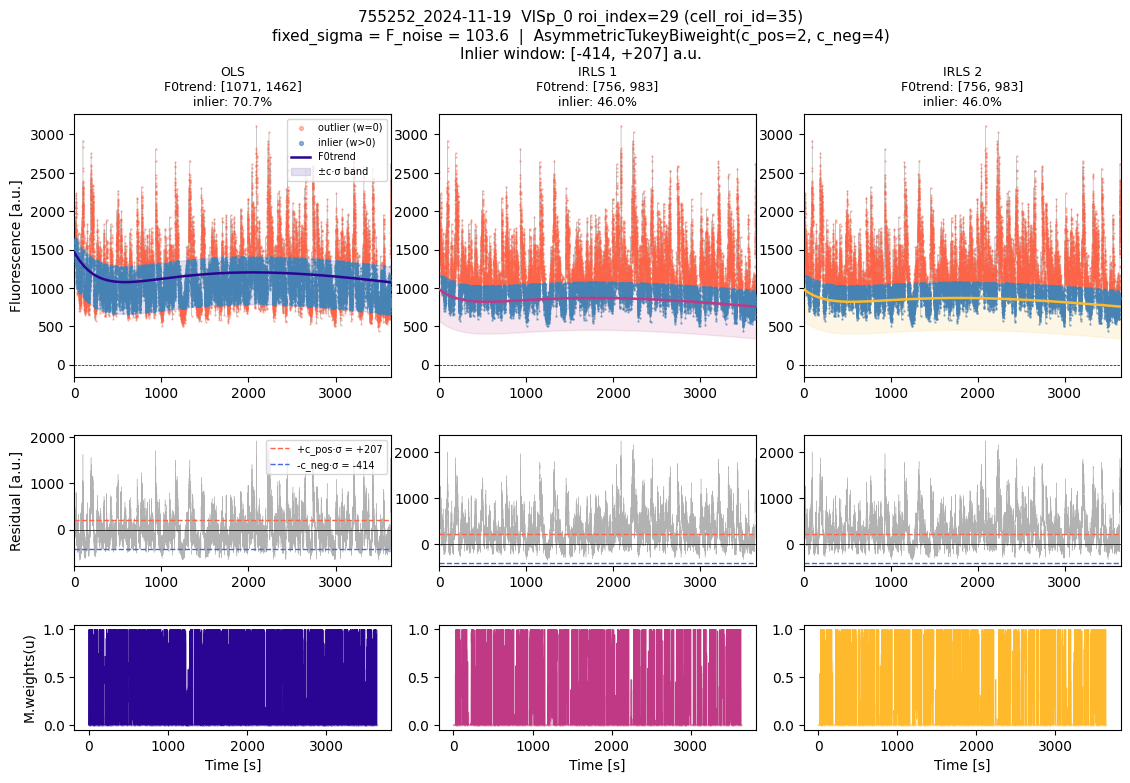

In [28]:
# ── Figure 1: F0trend progression across iterations ──────────────────────────
#
# Each column = one step.  Top row: F + F0trend + ±c*sigma band.
# Bottom row: per-frame weight (0 = excluded from gradient).

n_steps = len(history)
colors  = plt.cm.plasma(np.linspace(0.05, 0.85, n_steps))

fig = plt.figure(figsize=(4.5 * n_steps, 8))
gs  = gridspec.GridSpec(3, n_steps, height_ratios=[3, 1.5, 1.2], hspace=0.35, wspace=0.15)

for col, (step, c) in enumerate(zip(history, colors)):
    F0t   = step['F0trend']
    w     = step['weights']
    resid = step['resid']

    # ── row 0: F + F0trend + inlier/outlier band ──────────────────────────
    ax0 = fig.add_subplot(gs[0, col])

    inlier_mask  = w > 0
    outlier_mask = ~inlier_mask

    ax0.plot(timestamps, F, c='grey', lw=0.3, alpha=0.5, zorder=1)
    ax0.scatter(timestamps[outlier_mask], F[outlier_mask],
                c='tomato', s=0.5, alpha=0.4, zorder=2, label='outlier (w=0)')
    ax0.scatter(timestamps[inlier_mask], F[inlier_mask],
                c='steelblue', s=0.5, alpha=0.6, zorder=3, label='inlier (w>0)')
    ax0.plot(timestamps, F0t, c=c, lw=1.8, zorder=4, label='F0trend')

    # shade ±c*sigma band around F0trend
    ax0.fill_between(timestamps,
                     F0t - M.c_neg * fixed_sigma,
                     F0t + M.c_pos * fixed_sigma,
                     alpha=0.12, color=c, zorder=0, label=f'±c·σ band')

    ax0.axhline(0, c='k', lw=0.5, ls='--')
    ax0.set_title(
        f"{step['step']}\n"
        f"F0trend: [{F0t.min():.0f}, {F0t.max():.0f}]\n"
        f"inlier: {step['inlier_frac']:.1%}",
        fontsize=9
    )
    if col == 0:
        ax0.set_ylabel('Fluorescence [a.u.]')
        ax0.legend(markerscale=4, fontsize=7, loc='upper right')
    ax0.set_xlim(timestamps[0], timestamps[-1])

    # ── row 1: residuals with ±c*sigma threshold lines ────────────────────
    ax1 = fig.add_subplot(gs[1, col])
    ax1.plot(timestamps, resid, c='grey', lw=0.3, alpha=0.6)
    ax1.axhline(+M.c_pos * fixed_sigma, c='tomato', lw=1.0, ls='--',
                label=f'+c_pos·σ = +{M.c_pos*fixed_sigma:.0f}')
    ax1.axhline(-M.c_neg * fixed_sigma, c='royalblue', lw=1.0, ls='--',
                label=f'-c_neg·σ = -{M.c_neg*fixed_sigma:.0f}')
    ax1.axhline(0, c='k', lw=0.5)
    if col == 0:
        ax1.set_ylabel('Residual [a.u.]')
        ax1.legend(fontsize=7, loc='upper right')
    ax1.set_xlim(timestamps[0], timestamps[-1])

    # ── row 2: per-frame weight ────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[2, col])
    ax2.plot(timestamps, w, c=c, lw=0.5)
    ax2.fill_between(timestamps, 0, w, alpha=0.4, color=c)
    ax2.set_ylim(-0.05, 1.05)
    ax2.set_xlabel('Time [s]')
    if col == 0:
        ax2.set_ylabel('M.weights(u)')

fig.suptitle(
    f'755252_2024-11-19  VISp_0 roi_index=29 (cell_roi_id={cell_roi_id})\n'
    f'fixed_sigma = F_noise = {fixed_sigma:.1f}  |  '
    f'AsymmetricTukeyBiweight(c_pos={M.c_pos}, c_neg={M.c_neg})\n'
    f'Inlier window: [{-M.c_neg*fixed_sigma:.0f}, +{M.c_pos*fixed_sigma:.0f}] a.u.',
    fontsize=11, y=1.01
)
plt.tight_layout()
plt.show()

In [29]:
# ── Parameter evolution table ─────────────────────────────────────────────────

rows = []
for step in history:
    p = step['params']
    row = {'step': step['step']}
    for lbl, val in zip(PARAM_LABELS, p):
        row[lbl] = f'{val:.1f}'
    row['F0trend_min'] = f"{step['F0trend'].min():.1f}"
    row['F0trend_max'] = f"{step['F0trend'].max():.1f}"
    row['inlier_%']    = f"{step['inlier_frac']:.1%}"
    row['param_Δ']     = f"{step['param_change']:.2e}" if step['param_change'] is not None else '—'
    rows.append(row)

df_table = pd.DataFrame(rows).set_index('step')
print(df_table.to_string())

       b_inf  b_slow b_fast b_bright  t_slow t_fast t_bright F0trend_min F0trend_max inlier_%   param_Δ
step                                                                                                   
OLS      0.0  5518.8  805.6   4862.7  3595.7  300.0   2205.7      1071.4      1461.8    70.7%         —
IRLS 1   0.0  5471.0  367.4   4855.7  3438.0  300.0   2514.8       755.7       982.8    46.0%  6.58e-02
IRLS 2   0.0  5471.0  367.4   4855.7  3438.0  300.0   2514.8       755.7       982.8    46.0%  2.26e-07


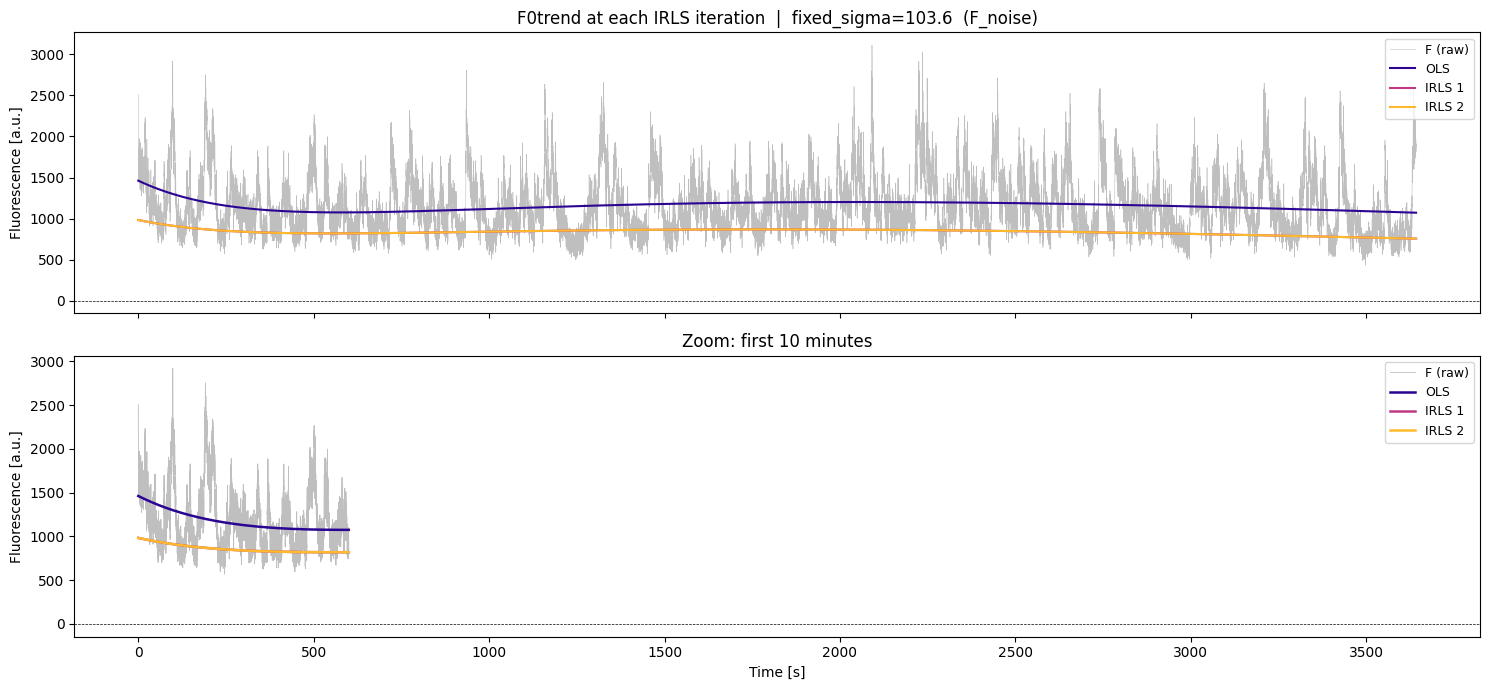

In [30]:
# ── Figure 2: All F0trends overlaid on F (single panel) ──────────────────────

fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True)

# Full session
ax = axes[0]
ax.plot(timestamps, F, c='grey', lw=0.4, alpha=0.5, label='F (raw)')
for step, c in zip(history, colors):
    ax.plot(timestamps, step['F0trend'], c=c, lw=1.5, label=step['step'])
ax.axhline(0, c='k', lw=0.5, ls='--')
ax.set_ylabel('Fluorescence [a.u.]')
ax.legend(loc='upper right', fontsize=9)
ax.set_title(f'F0trend at each IRLS iteration  |  fixed_sigma={fixed_sigma:.1f}  (F_noise)')

# Zoom: first 10 minutes
ax = axes[1]
zoom = timestamps <= 600
ax.plot(timestamps[zoom], F[zoom], c='grey', lw=0.6, alpha=0.5, label='F (raw)')
for step, c in zip(history, colors):
    ax.plot(timestamps[zoom], step['F0trend'][zoom], c=c, lw=1.8, label=step['step'])
ax.axhline(0, c='k', lw=0.5, ls='--')
ax.set_xlabel('Time [s]')
ax.set_ylabel('Fluorescence [a.u.]')
ax.legend(loc='upper right', fontsize=9)
ax.set_title('Zoom: first 10 minutes')

plt.tight_layout()
plt.show()

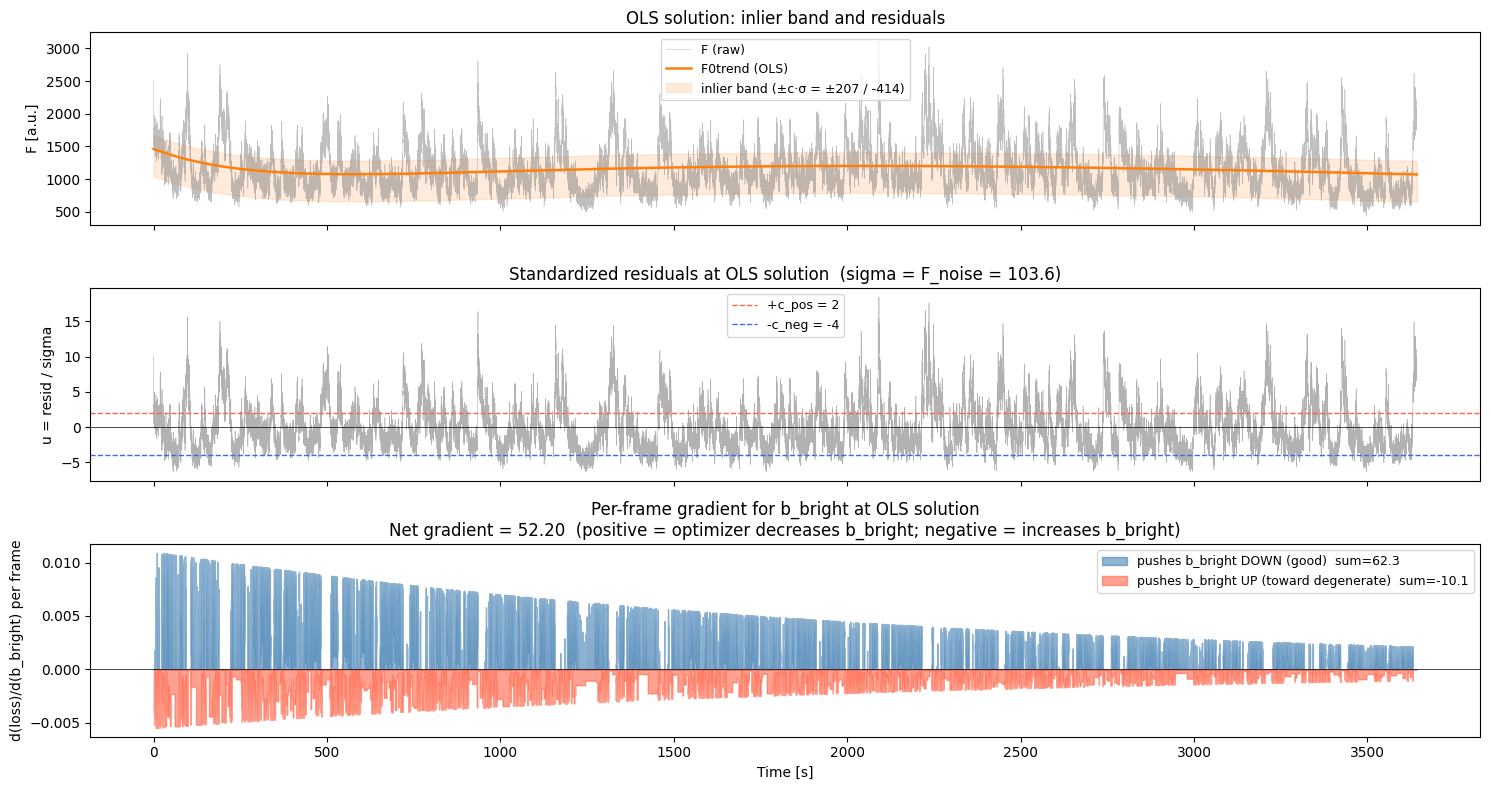

OLS b_bright = 4862.66
Net gradient for b_bright (OLS): 52.2046
Frames outside inlier window (zero psi, zero gradient): 29.3%


In [31]:
# ── Figure 3: Gradient contribution to b_bright at the OLS solution ───────────
#
# Shows which frames push b_bright up (toward degenerate state) vs down.
# d/d(b_bright) sum(M.rho(u_i)) = -sum(M.psi(u_i) * E_bright_i) / sigma
# Each frame's contribution: -M.psi(u_i) * E_bright_i / sigma
# Positive -> pushes b_bright down (good)
# Negative -> pushes b_bright up (toward degenerate state)

ols_step = history[0]   # OLS result
p_ols    = ols_step['params']
t_bright_ols = p_ols[6]
E_bright = np.exp(-timestamps / t_bright_ols)

u_ols    = ols_step['u']
psi_ols  = np.array(M.psi(u_ols))
grad_contrib = -psi_ols * E_bright / fixed_sigma  # per-frame gradient for b_bright

fig, axes = plt.subplots(3, 1, figsize=(15, 8), sharex=True)

ax = axes[0]
ax.plot(timestamps, F, c='grey', lw=0.4, alpha=0.5, label='F (raw)')
ax.plot(timestamps, ols_step['F0trend'], c='C1', lw=1.8, label='F0trend (OLS)')
ax.fill_between(timestamps,
                ols_step['F0trend'] - M.c_neg * fixed_sigma,
                ols_step['F0trend'] + M.c_pos * fixed_sigma,
                alpha=0.15, color='C1', label=f'inlier band (±c·σ = ±{M.c_pos*fixed_sigma:.0f} / -{M.c_neg*fixed_sigma:.0f})')
ax.set_ylabel('F [a.u.]')
ax.legend(fontsize=9)
ax.set_title('OLS solution: inlier band and residuals')

ax = axes[1]
ax.plot(timestamps, u_ols, c='grey', lw=0.4, alpha=0.6)
ax.axhline(+M.c_pos, c='tomato',    lw=1.0, ls='--', label=f'+c_pos = {M.c_pos}')
ax.axhline(-M.c_neg, c='royalblue', lw=1.0, ls='--', label=f'-c_neg = -{M.c_neg}')
ax.axhline(0, c='k', lw=0.5)
ax.set_ylabel('u = resid / sigma')
ax.legend(fontsize=9)
ax.set_title(f'Standardized residuals at OLS solution  (sigma = F_noise = {fixed_sigma:.1f})')

ax = axes[2]
pos_mask = grad_contrib >= 0
neg_mask = ~pos_mask
ax.fill_between(timestamps[pos_mask], 0, grad_contrib[pos_mask],
                step='mid', color='steelblue', alpha=0.6,
                label=f'pushes b_bright DOWN (good)  sum={grad_contrib[pos_mask].sum():.1f}')
ax.fill_between(timestamps[neg_mask], 0, grad_contrib[neg_mask],
                step='mid', color='tomato', alpha=0.6,
                label=f'pushes b_bright UP (toward degenerate)  sum={grad_contrib[neg_mask].sum():.1f}')
ax.axhline(0, c='k', lw=0.5)
ax.set_ylabel('d(loss)/d(b_bright) per frame')
ax.set_xlabel('Time [s]')
ax.legend(fontsize=9)
ax.set_title(
    f'Per-frame gradient for b_bright at OLS solution\n'
    f'Net gradient = {grad_contrib.sum():.2f}  '
    f'(positive = optimizer decreases b_bright; negative = increases b_bright)'
)

plt.tight_layout()
plt.show()

print(f"OLS b_bright = {p_ols[3]:.2f}")
print(f"Net gradient for b_bright (OLS): {grad_contrib.sum():.4f}")
print(f"Frames outside inlier window (zero psi, zero gradient): {(np.abs(u_ols) > np.where(u_ols>0, M.c_pos, M.c_neg)).mean():.1%}")